<a href="https://colab.research.google.com/github/brenaSF/RFM-Segmentation/blob/colab-notebook/RFM_Mapeamento_de_Perfil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentação de usuários/habitantes


## 1.Entendimento do Negócio

Resumo do projeto :

- Este projeto utiliza dados públicos da base de dados do IBGE, nomeado "Condições de Vida 2017".

- Objetivo: Realizar o mapeamento de perfis socioeconômicos através das condições de moradia,infraestrutura e padrão de vida

- Contexto : Como o mapeamento de perfis socioeconômicos influenciam na criação de planos de desenvolvimento sustentável?

Passos para o desenvolvimento do projeto :

1. Realizar da Análise Exploratória de Dados
2. Aplicar a Featuring Engeneering para geração de Indíces para avaliação da infraestrutura, vulnerabilidade alimentar e capacidade dos grupos sociais da pesquisa
3. Aplicar modelo de clustering

## 2.Entendimento dos dados

## Importação de Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Importação da base de dados condicçoes de vida 2017
data = pd.read_csv("br_ibge_pof_condicoes_vida_2017.csv")

In [ ]:
# Visualização dos valores do dataset
data.head(5)

,sigla_uf,situacao,id_estrato,id_unidade_primaria_amostragem,id_domicilio,id_unidade_consumo,id_informante,V61041,V61042,V61043,...,V6117,V6118,V6119,V6120,V6121,V6101,V6102,V6103,peso,peso_final
0,AC,1,1202,120004720,12000472002,1200047200201,120004720020101,2,2,2,...,NaN,NaN,NaN,NaN,NaN,3,1500,500,140.926331,166.548111
1,AC,1,1202,120004720,12000472003,1200047200301,120004720030101,2,2,2,...,2.0,2.0,2.0,2.0,2.0,4,5000,1500,140.926331,166.548111
2,AC,1,1202,120004720,12000472004,1200047200401,120004720040102,2,1,2,...,NaN,NaN,NaN,NaN,NaN,2,6000,1000,140.926331,166.548111
3,AC,1,1202,120004720,12000472005,1200047200501,120004720050102,1,2,2,...,NaN,NaN,NaN,NaN,NaN,3,1500,900,140.926331,166.548111
4,AC,1,1202,120004720,12000472010,1200047201001,120004720100101,1,1,1,...,NaN,NaN,NaN,NaN,NaN,4,2000,700,140.926331,166.548111


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58039 entries, 0 to 58038
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   sigla_uf                        58039 non-null  object 
 1   situacao                        58039 non-null  int64  
 2   id_estrato                      58039 non-null  int64  
 3   id_unidade_primaria_amostragem  58039 non-null  int64  
 4   id_domicilio                    58039 non-null  int64  
 5   id_unidade_consumo              58039 non-null  int64  
 6   id_informante                   58039 non-null  int64  
 7   V61041                          58039 non-null  int64  
 8   V61042                          58039 non-null  int64  
 9   V61043                          58039 non-null  int64  
 10  V61044                          58039 non-null  int64  
 11  V61045                          58039 non-null  int64  
 12  V61046                          

- Ao aplicar .info() foi descoberto variáveis com valores ausentes(V6112 à V6121), as quais estão relacionadas a Insegurança Alimentar do últimos 3 meses da amostra.
>  - Para variáveis que tinham como pré-requisito haver moradores menores de 18 anos, é provável que não haja nenhum integrante menor de idade.
>  - Para variáveis que tinham como pré-requisito haver moradores maiores de 18 anos, é provável que os moradores tenham respondido NÃO para perguntas anteriores, como "Indica se, segundo o informante, nos últimos três meses os alimentos acabaram antes que os moradores do domicílio tivessem dinheiro para comprar mais comida	" ou "Indica se, segundo o informante, nos últimos três meses os moradores do domicílio ficaram sem dinheiro para ter uma alimentação saudável e variada".

In [ ]:
print(data.isnull().sum())

sigla_uf                              0
situacao                              0
id_estrato                            0
id_unidade_primaria_amostragem        1
id_domicilio                          1
id_unidade_consumo                    1
id_informante                         1
V61041                                1
V61042                                1
V61043                                1
V61044                                1
V61045                                1
V61046                                1
V61051                                1
V61052                                1
V61053                                1
V61054                                1
V61055                                1
V61056                                1
V61057                                1
V61058                                1
V61061                                1
V61062                                1
V61063                                1
V61064                                1


Variáveis V6112 à V6115 concentram 27690 valores nulos e variáveis V6116 à V6121 concentram 35802 valores nulos. Desse modo, é necessário realizar tratamento adequado desses valores. A exclusão determinaria a diminuição drástica da base de dados , além de excluir núcleos familiares relevantes para o mapeamento socieconômico.
Dessa forma, uma alternativa é aplicar 0 em todas os espaços vazios.

## 3.Preparação dos dados

- Seleção de variáveis
- Limpeza
- Engenharia de recursos (Feature Engineering)
- Criação dos índices sintéticos.

In [ ]:
data.describe()

,situacao,id_estrato,id_unidade_primaria_amostragem,id_domicilio,id_unidade_consumo,id_informante,V61041,V61042,V61043,V61044,...,V6117,V6118,V6119,V6120,V6121,V6101,V6102,V6103,peso,peso_final
count,47435.000000,47435.000000,4.743400e+04,4.743400e+04,4.743400e+04,4.743400e+04,47434.000000,47434.000000,47434.000000,47434.000000,...,11633.000000,11633.000000,11633.000000,11633.000000,11633.000000,47434.000000,47434.000000,47434.000000,47434.000000,47434.000000
mean,1.243238,3099.629177,3.088702e+08,3.088702e+10,3.088702e+12,3.088702e+14,1.480879,1.425412,1.526163,1.524118,...,1.733087,1.721740,1.882661,1.893836,1.927534,2.928047,3383.444597,959.381246,792.327016,962.330355
std,0.429042,1208.909685,1.207290e+08,1.207290e+10,1.207290e+12,1.207290e+14,0.604154,0.631345,0.638342,0.700613,...,0.442366,0.448161,0.321837,0.308060,0.259270,1.226928,3861.539401,713.249506,727.746751,861.595193
min,1.000000,1101.000000,1.100000e+08,1.100000e+10,1.100000e+12,1.100000e+14,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,80.000000,50.000000,16.104575,23.170091
25%,1.000000,2304.000000,2.300209e+08,2.300209e+10,2.300209e+12,2.300209e+14,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1500.000000,500.000000,360.398843,458.771258
50%,1.000000,2917.000000,2.901159e+08,2.901159e+10,2.901159e+12,2.901159e+14,1.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2500.000000,800.000000,597.026154,735.517781
75%,1.000000,4132.000000,4.101527e+08,4.101527e+10,4.101527e+12,4.101527e+14,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,4000.000000,1000.000000,1056.688137,1284.489972
max,2.000000,5308.000000,5.300442e+08,5.300442e+10,5.300442e+12,5.300442e+14,3.000000,3.000000,3.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,6.000000,400000.000000,15000.000000,49579.041703,65991.328810


### Retirar rótulos com ID

In [ ]:
data = data.drop('id_estrato',axis =1)
data = data.drop('id_unidade_primaria_amostragem',axis =1)
data = data.drop('id_domicilio',axis =1)
data = data.drop('id_unidade_consumo',axis =1)
data = data.drop('id_informante',axis =1)

In [ ]:
data = data.drop('peso',axis =1)
data = data.drop('peso_final',axis =1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58039 entries, 0 to 58038
Data columns (total 47 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sigla_uf  58039 non-null  object 
 1   situacao  58039 non-null  int64  
 2   V61041    58039 non-null  int64  
 3   V61042    58039 non-null  int64  
 4   V61043    58039 non-null  int64  
 5   V61044    58039 non-null  int64  
 6   V61045    58039 non-null  int64  
 7   V61046    58039 non-null  int64  
 8   V61051    58039 non-null  int64  
 9   V61052    58039 non-null  int64  
 10  V61053    58039 non-null  int64  
 11  V61054    58039 non-null  int64  
 12  V61055    58039 non-null  int64  
 13  V61056    58039 non-null  int64  
 14  V61057    58039 non-null  int64  
 15  V61058    58039 non-null  int64  
 16  V61061    58039 non-null  int64  
 17  V61062    58039 non-null  int64  
 18  V61063    58039 non-null  int64  
 19  V61064    58039 non-null  int64  
 20  V61065    58039 non-null  in

In [ ]:
print(data.isnull().sum())

sigla_uf        0
situacao        0
V61041          0
V61042          0
V61043          0
V61044          0
V61045          0
V61046          0
V61051          0
V61052          0
V61053          0
V61054          0
V61055          0
V61056          0
V61057          0
V61058          0
V61061          0
V61062          0
V61063          0
V61064          0
V61065          0
V61066          0
V61067          0
V61068          0
V61069          0
V610610         0
V610611         0
V61071          0
V61072          0
V61073          0
V6108           0
V6109           0
V6110           0
V6111           0
V6112       34766
V6113       34766
V6114       34766
V6115       34766
V6116       44512
V6117       44512
V6118       44512
V6119       44512
V6120       44512
V6121       44512
V6101           0
V6102           0
V6103           0
dtype: int64


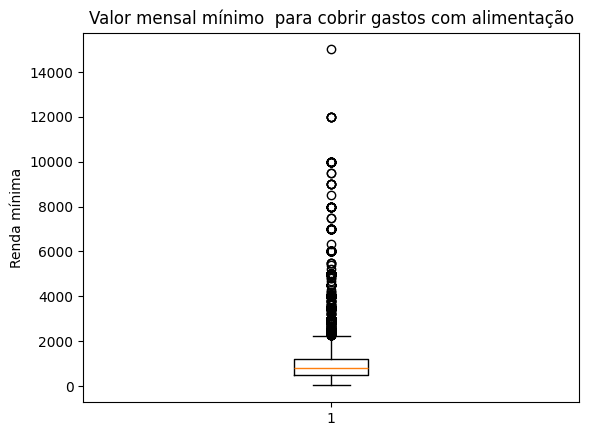

In [ ]:
# gerar boxplot da renda minima
plt.boxplot(data['V6103'])
plt.title("Valor mensal mínimo  para cobrir gastos com alimentação")
plt.ylabel("Renda mínima")
plt.show()

- O gráfico mostra valores discrepantes para o mínimo necessário para alimentação entre as famílias da amostra.

#### Hipóteses criadas a partir da análise do gráfico de boxplot:
- As famílias que informaram o valor mínimo acima de 2000 reais tem maior probabilidade de ter maior Segurança Alimentar - Depende do que é considerado básico para cada família e o tamanho


In [ ]:
linha_maximo_valor_alimentacao = data[data['V6103'] >= 10000]
print(linha_maximo_valor_alimentacao.head(10))

      sigla_uf  situacao  V61041  V61042  V61043  V61044  V61045  V61046  \
2886        AP         1       1       1       2       1       2       1   
4808        AM         1       1       1       1       1       1       2   
7160        BA         1       1       1       1       1       1       1   
7695        BA         1       1       2       1       1       2       2   
13304       DF         1       1       1       2       2       3       3   
16844       MG         1       1       1       1       1       1       3   
17630       MG         1       1       1       1       1       2       2   
19706       MG         1       1       3       1       2       1       1   
25127       MT         1       1       1       1       1       1       1   
28240       MS         1       2       2       2       2       2       3   

       V61051  V61052  ...  V6115  V6116  V6117  V6118  V6119  V6120  V6121  \
2886        2       1  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
4808 

### Seleção de variáveis

In [ ]:
# 3.1. Tratamento de Nulos
df_clean = data.fillna(0)

# 3.2. Função para conversão binária (Presença do problema = 1, Ausência = 0)
def binario(coluna):
    return np.where(coluna == 1, 1, 0)

# 3.3. Engenharia de Recursos (Criação dos Índices Sintéticos)
df_clean['IA_Score'] = (
    binario(df_clean['V6108']) + binario(df_clean['V6109']) +
    binario(df_clean['V6110']) + binario(df_clean['V6112']) +
    binario(df_clean['V6114']) + binario(df_clean['V6119'])
)

df_clean['Habitacao_Score'] = (
    binario(df_clean['V61061']) + binario(df_clean['V61063']) +
    binario(df_clean['V61064']) + binario(df_clean['V61065']) +
    binario(df_clean['V61068']) + binario(df_clean['V61069'])
)

df_clean['Financeiro_Score'] = (
    binario(df_clean['V61071']) + binario(df_clean['V61072']) +
    binario(df_clean['V61073'])
)

### Tratamento de valores nulos

In [ ]:
df_clean.isnull().sum()

,0
sigla_uf,0
situacao,0
V61041,0
V61042,0
V61043,0
V61044,0
V61045,0
V61046,0
V61051,0
V61052,0


In [ ]:
df_clean.head()

,sigla_uf,situacao,V61041,V61042,V61043,V61044,V61045,V61046,V61051,V61052,...,V6118,V6119,V6120,V6121,V6101,V6102,V6103,IA_Score,Habitacao_Score,Financeiro_Score
0,AC,1,2.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,...,0.0,0.0,0.0,0.0,3.0,1500.0,500.0,1,1,0
1,AC,1,2.0,2.0,2.0,2.0,3.0,3.0,3.0,2.0,...,2.0,2.0,2.0,2.0,4.0,5000.0,1500.0,0,1,0
2,AC,1,2.0,1.0,2.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,2.0,6000.0,1000.0,0,3,2
3,AC,1,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,3.0,1500.0,900.0,0,1,1
4,AC,1,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,4.0,2000.0,700.0,0,1,0


### Tratamento de Outliers

### Correlação de variáveis

In [ ]:
# dataset somente com números
data_num = data.select_dtypes(include=['number'])
data_num.head()

,situacao,V61041,V61042,V61043,V61044,V61045,V61046,V61051,V61052,V61053,...,V6117,V6118,V6119,V6120,V6121,V6101,V6102,V6103,peso,peso_final
0,1,2,2,2,3,3,3,2,2,2,...,NaN,NaN,NaN,NaN,NaN,3,1500,500,140.926331,166.548111
1,1,2,2,2,2,3,3,3,2,3,...,2.0,2.0,2.0,2.0,2.0,4,5000,1500,140.926331,166.548111
2,1,2,1,2,3,3,3,3,3,3,...,NaN,NaN,NaN,NaN,NaN,2,6000,1000,140.926331,166.548111
3,1,1,2,2,1,2,2,2,2,3,...,NaN,NaN,NaN,NaN,NaN,3,1500,900,140.926331,166.548111
4,1,1,1,1,2,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,4,2000,700,140.926331,166.548111


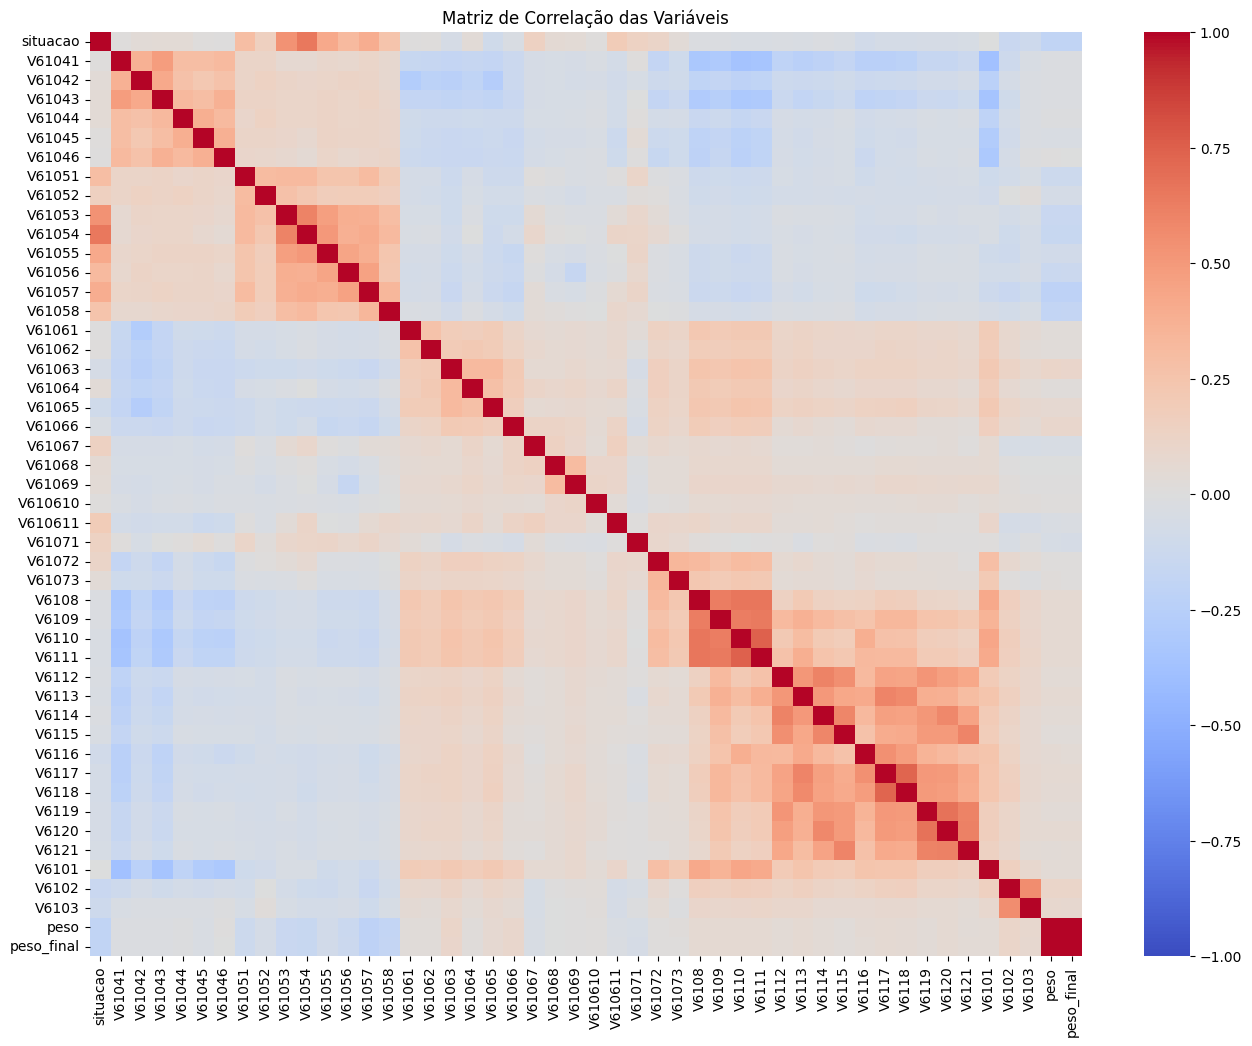

In [ ]:
plt.figure(figsize=(16, 12))
corr = data_num.corr()

# Criar o heatmap
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

In [ ]:
sns.pairplot(data, kind="scatter", plot_kws={'alpha':0.4})


## EDA

In [ ]:
data.describe()

### Análise do Padrão de Vida com relação a Alimentação


In [ ]:
# 1. Guardar rótulo em variável que será utilizada para pegar indíces e total de vlaore por indíces
padrao_alimentacao = data['V61041'].value_counts()
print(padrao_alimentacao)

In [ ]:
# 1. Mapear
# 2. Replace com os novos valores
# 3. Guardar atributo em variável para utilização dos indíces e o total de valores por indíces

dict_alimentacao  = {1:"Bom", 2:"Satisfatório", 3:"Ruim"}
print(dict_alimentacao)

data['V61041_rotulo'] = data['V61041'].replace(dict_alimentacao)
data['V61041_rotulo'] = data['V61041_rotulo'].astype('category')

padrao_alimentacao_rotulo = data['V61041_rotulo'].value_counts()
print(padrao_alimentacao_rotulo)

In [ ]:
# 1. Criar gráfico de barrar com barplot (dados categóricos)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(
    x=padrao_alimentacao_rotulo.index.astype(str),
    height=padrao_alimentacao_rotulo.values,
    color='skyblue',
    edgecolor='black'
)

plt.title("Padrão de vida em relação a alimentação")
plt.xlabel("V61041")
plt.ylabel("Quantidade de Moradores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Análise do Padrão de Vida com relação ao fornecimento de água


In [ ]:
# 1. Guardar rótulo em variável que será utilizada para pegar indíces e total de vlaore por indíces
padrao_fornecimento_agua = data['V61051'].value_counts()
print(padrao_fornecimento_agua)

In [ ]:
# 1. Mapear
# 2. Replace com novos valores
# 3. Guardar rótulo com o novo mapeamento dos indíces

dict_agua = {1:"Bom", 2:"Satisfatório", 3:"Ruim", 4:"Indisponível"}
print(dict_agua)

data['V61051_rotulo'] = data['V61051'].replace(dict_agua)
data['V61051_rotulo'] = data['V61051_rotulo'].astype('category')

padrao_fornecimento_agua_rotulo = data['V61051_rotulo'].value_counts()
print(padrao_fornecimento_agua_rotulo)

In [ ]:
# Criar gráfico

plt.figure(figsize=(10,6))
plt.bar(
    x=padrao_fornecimento_agua_rotulo.index.astype(str),
    height=padrao_fornecimento_agua_rotulo.values,
    color='skyblue',
    edgecolor='black'
)

plt.title("Padrão de vida em relação a água")
plt.xlabel("V61051")
plt.ylabel("Quantidade de Moradores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()